In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="deep")

DATA_DIR = Path.cwd()
files = ["Orders.csv", "Products.csv", "Returns.csv", "Delivery.csv", "Inventory.csv"]

orders = pd.read_csv(DATA_DIR / "Orders.csv")
products = pd.read_csv(DATA_DIR / "Products.csv")
returns = pd.read_csv(DATA_DIR / "Returns.csv")
delivery = pd.read_csv(DATA_DIR / "Delivery.csv")
inventory = pd.read_csv(DATA_DIR / "Inventory.csv")
datasets = {"Orders": orders, "Products": products, "Returns": returns, "Delivery": delivery, "Inventory": inventory}
display(pd.DataFrame({"Dataset": list(datasets), "Rows": [len(x) for x in datasets.values()], "Columns": [x.shape[1] for x in datasets.values()]}))

,Dataset,Rows,Columns
0,Orders,10000,10
1,Products,51,6
2,Returns,1000,9
3,Delivery,10000,6
4,Inventory,5100,6


## 1. Data quality and relationship checks

In [3]:
def quality_report(frame, name):
    return pd.Series({"Dataset": name, "Rows": len(frame), "Columns": frame.shape[1], "Duplicate rows": int(frame.duplicated().sum()), "Missing cells": int(frame.isna().sum().sum())})
display(pd.DataFrame([quality_report(v, k) for k, v in datasets.items()]))

,Dataset,Rows,Columns,Duplicate rows,Missing cells
0,Orders,10000,10,0,0
1,Products,51,6,0,0
2,Returns,1000,9,0,0
3,Delivery,10000,6,0,0
4,Inventory,5100,6,0,0


In [4]:
for dataset_name, dataframe in datasets.items():
    print(f"\n{dataset_name}")
    print(dataframe.dtypes)


Orders
OrderID                 int64
CustomerID              int64
OrderDateTime             str
ProductID               int64
Quantity                int64
TotalAmount             int64
StoreID                 int64
OrderStatus               str
ExpectedDeliveryTime      str
ActualDeliveryTime        str
dtype: object

Products
ProductID        int64
ProductName        str
Category           str
Brand              str
PricePerUnit     int64
StockQuantity    int64
dtype: object

Returns
ReturnID        int64
OrderID         int64
ProductID       int64
CustomerID      int64
StoreID         int64
ReturnReason      str
ReturnDate        str
RefundAmount    int64
ReturnStatus      str
dtype: object

Delivery
DeliveryID               int64
OrderID                  int64
DeliveryPartnerName        str
PickupTime                 str
DeliveryEndTime            str
DistanceTraveled       float64
dtype: object

Inventory
InventoryID      int64
StoreID          int64
ProductID        int64
Stock

In [5]:
#datetypes are in string, need conversion
orders["OrderDateTime"] = pd.to_datetime(orders["OrderDateTime"], errors="coerce")
orders["ExpectedDeliveryTime"] = pd.to_datetime(orders["ExpectedDeliveryTime"], errors="coerce")
orders["ActualDeliveryTime"] = pd.to_datetime(orders["ActualDeliveryTime"], errors="coerce")
returns["ReturnDate"] = pd.to_datetime(returns["ReturnDate"], errors="coerce")
inventory["LastUpdated"] = pd.to_datetime(inventory["LastUpdated"], errors="coerce")

In [6]:
# evaluating the datasets
checks = {
    "OrderID unique": orders["OrderID"].is_unique,
    "ProductID unique in master": products["ProductID"].is_unique,
    "Delivery orders matched": f"{delivery['OrderID'].isin(orders['OrderID']).mean():.1%}",
    "Return orders matched": f"{returns['OrderID'].isin(orders['OrderID']).mean():.1%}",
    "Inventory store-product unique": not inventory.duplicated(["StoreID", "ProductID"]).any(),
    "Negative quantities": int((orders["Quantity"] < 0).sum()),
    "Negative revenue": int((orders["TotalAmount"] < 0).sum()),
    "Negative refunds": int((returns["RefundAmount"] < 0).sum()),
}
display(pd.DataFrame({"Check": checks.keys(), "Result": checks.values()}))

,Check,Result
0,OrderID unique,True
1,ProductID unique in master,True
2,Delivery orders matched,100.0%
3,Return orders matched,100.0%
4,Inventory store-product unique,True
5,Negative quantities,0
6,Negative revenue,0
7,Negative refunds,0


## 2. Build the analysis-ready data model

In [7]:
orders["delay_minutes"] = (orders["ActualDeliveryTime"] - orders["ExpectedDeliveryTime"]).dt.total_seconds() / 60
orders["delay_only_minutes"] = orders["delay_minutes"].clip(lower=0)
orders["actual_delivery_minutes"] = (orders["ActualDeliveryTime"] - orders["OrderDateTime"]).dt.total_seconds() / 60
orders["delivery_status"] = np.select([orders["delay_minutes"] < 0, orders["delay_minutes"] == 0], ["Early", "On Time"], default="Delayed")
orders["on_time"] = orders["delivery_status"].isin(["Early", "On Time"])
orders["month"] = orders["OrderDateTime"].dt.to_period("M").astype(str)
orders["day_of_week"] = orders["OrderDateTime"].dt.day_name()
orders["order_hour"] = orders["OrderDateTime"].dt.hour

def elapsed_seconds(value):
    try:
        a, b = str(value).split(":")
        return float(a) * 60 + float(b)
    except (ValueError, TypeError):
        return np.nan
delivery["delivery_duration_minutes"] = (delivery["DeliveryEndTime"].map(elapsed_seconds) - delivery["PickupTime"].map(elapsed_seconds)) / 60
delivery.loc[delivery["delivery_duration_minutes"] < 0, "delivery_duration_minutes"] += 60

returns_by_order = returns.groupby(["OrderID", "ProductID"], as_index=False).agg(Return_Count=("ReturnID", "count"), Refund_Amount=("RefundAmount", "sum"), Return_Reason=("ReturnReason", "first"))
latest_inventory = inventory.sort_values("LastUpdated").drop_duplicates(["StoreID", "ProductID"], keep="last")
analysis = (orders.merge(products, on="ProductID", how="left", validate="many_to_one")
                 .merge(delivery[["OrderID", "DeliveryPartnerName", "DistanceTraveled", "delivery_duration_minutes"]], on="OrderID", how="left", validate="one_to_one")
                 .merge(returns_by_order, on=["OrderID", "ProductID"], how="left")
                 .merge(latest_inventory[["StoreID", "ProductID", "StockQuantity", "ReorderLevel"]], on=["StoreID", "ProductID"], how="left"))
for c, default in [("Return_Count", 0), ("Refund_Amount", 0)]: analysis[c] = analysis[c].fillna(default)
analysis["returned"] = analysis["Return_Count"].gt(0)
analysis["stock_status"] = np.where(analysis["StockQuantity_y"] <= analysis["ReorderLevel"], "Reorder", "Healthy")
display(analysis.head(3))
display(pd.DataFrame({"Join check": ["Order rows", "Joined rows", "Missing product match", "Missing delivery match", "Missing inventory match"], "Value": [len(orders), len(analysis), int(analysis["ProductName"].isna().sum()), int(analysis["DeliveryPartnerName"].isna().sum()), int(analysis["StockQuantity_y"].isna().sum())]}))

,OrderID,CustomerID,OrderDateTime,ProductID,Quantity,TotalAmount,StoreID,OrderStatus,ExpectedDeliveryTime,ActualDeliveryTime,...,DeliveryPartnerName,DistanceTraveled,delivery_duration_minutes,Return_Count,Refund_Amount,Return_Reason,StockQuantity_y,ReorderLevel,returned,stock_status
0,3001,6001,2025-01-22 20:02:03.428463,1025,2,90,2051,Delivered,2025-01-22 20:12:03.428463,2025-01-22 20:27:03.428463,...,Arjun Nair,1.98,23.0,0.0,0.0,NaN,570,100,False,Healthy
1,3002,6002,2025-02-18 15:58:03.428463,1027,1,99,2084,Delivered,2025-02-18 16:08:03.428463,2025-02-18 16:10:03.428463,...,Arjun Nair,7.93,10.0,0.0,0.0,NaN,551,100,False,Healthy
2,3003,6003,2025-02-04 06:58:03.428463,1001,3,780,2008,Delivered,2025-02-04 07:08:03.428463,2025-02-04 07:10:03.428463,...,Rohit Sharma,4.67,10.0,0.0,0.0,NaN,177,100,False,Healthy


,Join check,Value
0,Order rows,10000
1,Joined rows,10000
2,Missing product match,0
3,Missing delivery match,0
4,Missing inventory match,0


In [8]:
analysis.to_csv("final_united_dataset.csv")

## 3. Executive KPI scorecard

In [9]:
total_orders = analysis["OrderID"].nunique()
total_revenue = analysis["TotalAmount"].sum()
avg_order_value = analysis["TotalAmount"].mean()
avg_delivery_time = analysis["actual_delivery_minutes"].mean()
on_time_rate = analysis["on_time"].mean()
delay_rate = analysis["delivery_status"].eq("Delayed").mean()
return_rate = analysis["returned"].mean()
refund_total = analysis["Refund_Amount"].sum()
inventory_value = (latest_inventory.merge(products[["ProductID", "PricePerUnit"]], on="ProductID").eval("StockQuantity * PricePerUnit")).sum()
reorder_pairs = int(latest_inventory.eval("StockQuantity <= ReorderLevel").sum())
kpi = pd.DataFrame({"KPI": ["Total orders", "Total revenue", "Average order value", "Average delivery time", "On-time delivery", "Delay rate", "Return rate", "Refund value", "Inventory value", "Pairs at/below reorder"], "Value": [f"{total_orders:,}", f"₹{total_revenue:,.0f}", f"₹{avg_order_value:,.2f}", f"{avg_delivery_time:,.1f} minutes", f"{on_time_rate:.1%}", f"{delay_rate:.1%}", f"{return_rate:.1%}", f"₹{refund_total:,.0f}", f"₹{inventory_value:,.0f}", f"{reorder_pairs:,}"]})
display(kpi)

,KPI,Value
0,Total orders,"10,000"
1,Total revenue,"₹5,014,167"
2,Average order value,₹501.42
3,Average delivery time,16.4 minutes
4,On-time delivery,20.1%
5,Delay rate,79.9%
6,Return rate,10.0%
7,Refund value,"₹479,203"
8,Inventory value,"₹448,286,264"
9,Pairs at/below reorder,262


## 4. Delivery performance and customer impact

In [10]:
status_summary = analysis.groupby("delivery_status").agg(Orders=("OrderID", "count"), Revenue=("TotalAmount", "sum"), Avg_Delay_Minutes=("delay_only_minutes", "mean")).reindex(["Early", "On Time", "Delayed"]).fillna(0)
display(status_summary)

,Orders,Revenue,Avg_Delay_Minutes
delivery_status,,,
Early,0.0,0.0,0.000000
On Time,2010.0,1025791.0,0.000000
Delayed,7990.0,3988376.0,8.025782


In [11]:
reason_summary = returns.groupby("ReturnReason").agg(Returns=("ReturnID", "count"), Refund_Value=("RefundAmount", "sum")).sort_values("Returns", ascending=False)
display(reason_summary)

,Returns,Refund_Value
ReturnReason,,
Stale Product,522,249275
Damaged Item,478,229928


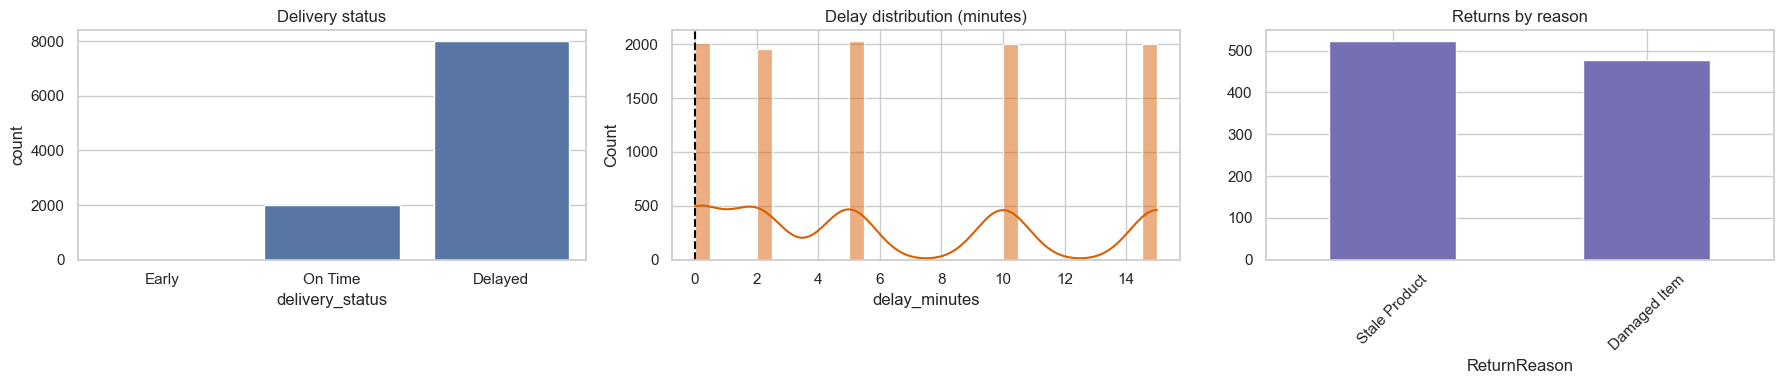

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(data=analysis, x="delivery_status", order=["Early", "On Time", "Delayed"], ax=axes[0]); axes[0].set_title("Delivery status")
sns.histplot(analysis["delay_minutes"], bins=30, kde=True, ax=axes[1], color="#d95f02"); axes[1].axvline(0, ls="--", color="black"); axes[1].set_title("Delay distribution (minutes)")
reason_summary["Returns"].plot(kind="bar", ax=axes[2], color="#7570b3", title="Returns by reason"); axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 5. Store, product, category, inventory, and time views

In [13]:
store_summary = analysis.groupby("StoreID").agg(Orders=("OrderID", "count"), Revenue=("TotalAmount", "sum"), AOV=("TotalAmount", "mean"), Avg_Delivery_Minutes=("actual_delivery_minutes", "mean"), Delay_Rate=("delivery_status", lambda x: x.eq("Delayed").mean()), Return_Rate=("returned", "mean"), Reorder_Pairs=("stock_status", lambda x: x.eq("Reorder").sum())).sort_values("Revenue", ascending=False)
display(store_summary.head(15))

,Orders,Revenue,AOV,Avg_Delivery_Minutes,Delay_Rate,Return_Rate,Reorder_Pairs
StoreID,,,,,,,
2016,125,71038,568.304000,16.888000,0.848000,0.120000,2
2063,111,67866,611.405405,16.891892,0.837838,0.135135,1
2079,110,67439,613.081818,16.718182,0.800000,0.081818,4
2002,108,65430,605.833333,15.824074,0.768519,0.101852,11
2066,115,64717,562.756522,17.347826,0.800000,0.113043,10
2045,121,61104,504.991736,16.165289,0.818182,0.123967,11
2010,108,60439,559.620370,16.250000,0.750000,0.111111,4
2094,106,60370,569.528302,15.811321,0.801887,0.075472,2
2022,119,60329,506.966387,16.453782,0.823529,0.084034,8


In [14]:
category_summary = analysis.groupby("Category").agg(Orders=("OrderID", "count"), Revenue=("TotalAmount", "sum"), Quantity=("Quantity", "sum"), Delay_Rate=("delivery_status", lambda x: x.eq("Delayed").mean()), Return_Rate=("returned", "mean")).sort_values("Revenue", ascending=False)
display(category_summary)

,Orders,Revenue,Quantity,Delay_Rate,Return_Rate
Category,,,,,
Grocery,2315,1481783,6935,0.794816,0.098488
Personal Care,2181,1253595,6480,0.797799,0.094452
Beverages,2178,1023266,6464,0.814509,0.100092
Snacks,1550,461932,4615,0.790968,0.103871
Dairy,799,384661,2374,0.797247,0.117647
Health,171,180600,516,0.748538,0.058480
Fruits,394,135900,1183,0.796954,0.093909
Electronics,221,71500,650,0.828054,0.090498
Vegetables,191,20930,598,0.774869,0.136126


In [15]:
product_summary = analysis.groupby(["ProductID", "ProductName", "Category"]).agg(Orders=("OrderID", "count"), Revenue=("TotalAmount", "sum"), Quantity=("Quantity", "sum"), Return_Rate=("returned", "mean")).sort_values("Revenue", ascending=False)
display(product_summary.head(15))

,,,Orders,Revenue,Quantity,Return_Rate
ProductID,ProductName,Category,,,,
1021,Patanjali Ghee 1L,Grocery,196,351014,586,0.071429
1029,Horlicks Classic Malt 1kg,Beverages,203,231000,600,0.098522
1047,Head & Shoulders Shampoo 650ml,Personal Care,188,219065,569,0.079787
1032,Whisper Ultra Pads (30 pcs),Personal Care,214,212160,663,0.102804
1037,Dabur Chyawanprash 1kg,Health,171,180600,516,0.058480
1041,Nestle Everyday Milk Powder 500g,Dairy,199,169125,615,0.105528
1026,Gillette Mach3 Razor,Personal Care,183,166842,558,0.087432
1017,Tata Tea Premium 500g,Beverages,209,153840,641,0.057416
1001,Amul Butter 500g,Dairy,200,148200,570,0.135000


In [16]:
inventory_view = latest_inventory.merge(products[["ProductID", "ProductName", "Category", "PricePerUnit"]], on="ProductID").assign(Stock_Value=lambda x: x["StockQuantity"] * x["PricePerUnit"], Stock_Status=lambda x: np.where(x["StockQuantity"] <= x["ReorderLevel"], "Reorder", "Healthy"))
display(inventory_view.groupby("Stock_Status").agg(Pairs=("ProductID", "count"), Stock_Value=("Stock_Value", "sum")))

,Pairs,Stock_Value
Stock_Status,,
Healthy,4838,445084295
Reorder,262,3201969


In [ ]:
monthly = analysis.groupby("month").agg(Orders=("OrderID", "count"), Revenue=("TotalAmount", "sum"), Delay_Rate=("delivery_status", lambda x: x.eq("Delayed").mean()))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday = analysis.groupby("day_of_week").agg(Orders=("OrderID", "count"), Revenue=("TotalAmount", "sum"), Delay_Rate=("delivery_status", lambda x: x.eq("Delayed").mean())).reindex(weekday_order)
hourly = analysis.groupby("order_hour").agg(Orders=("OrderID", "count"), Delay_Rate=("delivery_status", lambda x: x.eq("Delayed").mean()))
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
monthly["Revenue"].plot(marker="o", ax=axes[0], title="Monthly revenue"); axes[0].tick_params(axis="x", rotation=45)
weekday["Orders"].plot(kind="bar", ax=axes[1], color="#e7298a", title="Orders by weekday"); axes[1].tick_params(axis="x", rotation=45)
hourly["Delay_Rate"].plot(marker="o", ax=axes[2], color="#66a61e", title="Delay rate by order hour"); axes[2].set_ylabel("Delay rate")
plt.tight_layout(); plt.show()

## 6. Delivery partner performance and store performance matrix

In [ ]:
partner_summary = analysis.groupby("DeliveryPartnerName").agg(Deliveries=("OrderID", "count"), Avg_Duration_Minutes=("delivery_duration_minutes", "mean"), Avg_Distance=("DistanceTraveled", "mean"), Delay_Rate=("delivery_status", lambda x: x.eq("Delayed").mean()), Avg_Delay_Minutes=("delay_only_minutes", "mean")).sort_values("Delay_Rate", ascending=False)
display(partner_summary)
rev_mid, delay_mid = store_summary["Revenue"].median(), store_summary["Delay_Rate"].median()
store_summary["Performance_Segment"] = np.select([(store_summary["Revenue"] >= rev_mid) & (store_summary["Delay_Rate"] >= delay_mid), (store_summary["Revenue"] >= rev_mid) & (store_summary["Delay_Rate"] < delay_mid), (store_summary["Revenue"] < rev_mid) & (store_summary["Delay_Rate"] >= delay_mid)], ["High revenue / high delay", "High revenue / low delay", "Low revenue / high delay"], default="Low revenue / low delay")
display(store_summary["Performance_Segment"].value_counts().to_frame("Stores"))

## 7. Findings

In [ ]:
top_store = store_summary.index[0]
worst_store = store_summary["Delay_Rate"].idxmax()
top_category = category_summary.index[0]
top_reason = reason_summary.index[0]
worst_partner = partner_summary["Delay_Rate"].idxmax()
findings = [
    f"Store {top_store} is the top revenue store at ₹{store_summary.loc[top_store, 'Revenue']:,.0f}.",
    f"Store {worst_store} has the highest delay rate at {store_summary.loc[worst_store, 'Delay_Rate']:.1%};",
    f"{top_category} leads category revenue at ₹{category_summary.loc[top_category, 'Revenue']:,.0f}.",
    f"'{top_reason}' is the most common return reason ({int(reason_summary.loc[top_reason, 'Returns']):,} returns).",
    f"{worst_partner} has the highest delayed delivery-partner delay rate at {partner_summary.loc[worst_partner, 'Delay_Rate']:.1%}."
]
print(findings)